In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
from datetime import datetime

# 设置中文字体和绘图样式
sns.set_style("whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 8)
warnings.filterwarnings('ignore')

In [2]:
df_weather = pd.read_csv('../../data/raw/气象总表.csv', encoding='utf-8')
df_market = pd.read_csv('../../data/raw/市场边界_出清价格总表.csv', encoding='utf-8')
df_market['时段'] = df_market['时段'].str.split('-').str[1]
df_weather['日期'] = pd.to_datetime(df_weather['日期'])
df_market['日期'] = pd.to_datetime(df_market['日期'])
df_weather['时段'] = df_weather['时段'].astype(str)
df_market['时段'] = df_market['时段'].astype(str)

print(df_weather.shape) 
print(df_market.shape)

(9576, 318)
(9576, 26)


In [3]:
def calculate_zero_rate(df, name):
    # 1. 将缺失值 (NaN) 填充为 0
    df_filled = df.fillna(0)
    
    # 2. 统计 0 的数量 (包括原本的 0 和填充进来的 0)
    # 注意：这里只统计数值型列，避免对字符串列报错
    zero_counts = (df_filled == 0).sum()
    
    # 3. 计算总行数
    total_rows = len(df_filled)
    
    # 4. 计算含 0 率
    zero_rate = (zero_counts / total_rows) * 100
    
    print(f"\n=== {name} 含0率统计 (缺失值视为0) ===")
    # 只显示含0率大于0的列，并按比例降序排列
    result = zero_rate[zero_rate > 0].sort_values(ascending=False)
    
    if result.empty:
        print("无含0列")
    else:
        print(result.round(2)) # 保留两位小数

# 执行统计
calculate_zero_rate(df_weather, "气象数据集")
calculate_zero_rate(df_market, "市场数据集")


=== 气象数据集 含0率统计 (缺失值视为0) ===
襄阳市-降雨量-源2-预测    83.87
荆州市-降雨量-源2-预测    82.52
黄冈市-降雨量-源2-预测    81.47
黄冈市-降雨量-源6-预测    81.24
宜昌市-降雨量-源2-预测    80.96
                 ...  
荆州市-温度-源5-预测      0.09
孝感市-风速-源5-预测      0.08
孝感市-温度-源5-预测      0.06
襄阳市-风速-源5-预测      0.06
荆州市-风速-源5-预测      0.02
Length: 308, dtype: float64

=== 市场数据集 含0率统计 (缺失值视为0) ===
是否周末                71.43
是否高峰时段              66.67
是否夜间                62.50
光伏出力-实时             38.13
光伏出力-日前             30.01
风电出力-实时             12.80
水电出力-实时             11.16
系统负荷-实时             10.45
非市场化机组出力-实时         10.38
联络线计划-实时             4.76
小时                   4.17
平均出清价格-日前（元/MWh）     3.69
平均出清价格-实时（元/MWh）     1.92
风电出力-日前              0.75
联络线计划-日前             0.75
dtype: float64


In [4]:
def remove_high_zero_cols(df, name, threshold=0.8):
    # 1. 将缺失值填充为 0
    df_filled = df.fillna(0)
    
    # 2. 计算含 0 率
    # (df_filled == 0) 生成布尔表，.mean() 计算 True 的比例 (即含0率)
    zero_rate = (df_filled == 0).mean()
    
    # 3. 筛选出含0率大于阈值的列
    cols_to_drop = zero_rate[zero_rate > threshold].index.tolist()
    
    # 4. 执行删除
    if cols_to_drop:
        df.drop(columns=cols_to_drop, inplace=True)
        print(f"✅ [{name}] 已删除 {len(cols_to_drop)} 个含0率 > {threshold*100}% 的列")
        print(cols_to_drop)
    else:
        print(f"✅ [{name}] 无含0率 > {threshold*100}% 的列")
        
    return df

# 执行清洗 (删除含0率大于80%的列)
df_weather = remove_high_zero_cols(df_weather, "气象数据集", threshold=0.8)
df_market = remove_high_zero_cols(df_market, "市场数据集", threshold=0.8)

✅ [气象数据集] 已删除 7 个含0率 > 80.0% 的列
['宜昌市-降雨量-源2-预测', '宜昌市-降雨量-源6-预测', '荆州市-降雨量-源2-预测', '襄阳市-降雨量-源2-预测', '襄阳市-降雨量-源4-预测', '黄冈市-降雨量-源2-预测', '黄冈市-降雨量-源6-预测']
✅ [市场数据集] 无含0率 > 80.0% 的列


In [5]:
# 检查缺失值
missing_data = df_weather.isnull().sum()
missing_percentage = (missing_data / len(df_weather)) * 100

print("=== 缺失值统计 ===")
missing_info = pd.DataFrame({
    '缺失数量': missing_data,
    '缺失比例(%)': missing_percentage.round(2)
})
missing_info = missing_info[missing_info['缺失数量'] > 0].sort_values('缺失比例(%)', ascending=False)

if len(missing_info) > 0:
    display(missing_info)
else:
    print("✓ 无缺失值")

missing_data = df_market.isnull().sum()
missing_percentage = (missing_data / len(df_market)) * 100

print("=== 缺失值统计 ===")
missing_info = pd.DataFrame({
    '缺失数量': missing_data,
    '缺失比例(%)': missing_percentage.round(2)
})
missing_info = missing_info[missing_info['缺失数量'] > 0].sort_values('缺失比例(%)', ascending=False)

if len(missing_info) > 0:
    display(missing_info)
else:
    print("✓ 无缺失值")

=== 缺失值统计 ===


,缺失数量,缺失比例(%)
孝感市-总云量-源7-实际,3156,32.96
随州市-总云量-源7-实际,3156,32.96
宜昌市-总云量-源7-实际,3156,32.96
荆门市-总云量-源7-实际,3156,32.96
襄阳市-总云量-源7-实际,3156,32.96
...,...,...
宜昌市-降雨量-源4-预测,140,1.46
荆门市-风速-源5-预测,13,0.14
荆门市-总云量-源5-预测,13,0.14
荆门市-压强-源5-预测,13,0.14


=== 缺失值统计 ===


,缺失数量,缺失比例(%)
风电出力-实时,1224,12.78
光伏出力-实时,1224,12.78
水电出力-实时,1058,11.05
系统负荷-实时,992,10.36
非市场化机组出力-实时,986,10.30
联络线计划-实时,456,4.76
平均出清价格-日前（元/MWh）,216,2.26
风电出力-日前,72,0.75
光伏出力-日前,72,0.75
联络线计划-日前,72,0.75


In [6]:
def calculate_smape(y_true, y_pred):
    """
    计算对称平均绝对百分比误差 (sMAPE)
    公式: (1/n) * Σ(2 * |y_true - y_pred| / (|y_true| + |y_pred|)) * 100%
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # 避免除以0的情况
    denominator = (np.abs(y_true) + np.abs(y_pred))
    mask = denominator != 0
    
    if mask.sum() == 0:
        return np.nan
    
    smape = np.mean(2 * np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100
    return smape

def calculate_rmse(y_true, y_pred):
    """
    计算均方根误差 (RMSE)
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def analyze_weather_data(df_weather, city, weather_type):
    """
    分析选定城市和气象类型的不同数据源之间的相关性
    
    参数:
        df_weather: 气象数据
        city: 城市名称，如 '孝感市', '宜昌市', '武汉市', '荆州市'
        weather_type: 气象类型，如 '温度', '风速', '总云量', '相对湿度', '压强', '辐照度', '降雨量'
    
    返回:
        包含Spearman相关性、RMSE、sMAPE的结果字典
    """
    # 读取数据
    df = df_weather.copy()
    
    # 筛选出选定城市和气象类型的列
    pattern = f"{city}-{weather_type}"
    selected_cols = [col for col in df.columns if pattern in col]
    
    if len(selected_cols) == 0:
        print(f"未找到 {city} 的 {weather_type} 数据")
        return None
    
    print(f"找到以下列: {selected_cols}")
    
    # 提取数据
    data = df[selected_cols].copy()
    
    # 删除所有值都为空的行
    data = data.dropna(how='all')
    
    # 分离预测列和实际列
    pred_cols = [col for col in selected_cols if '预测' in col]
    actual_cols = [col for col in selected_cols if '实际' in col]
    
    print(f"\n预测数据源: {pred_cols}")
    print(f"实际数据源: {actual_cols}")
    
    results = {
        '预测vs预测': {},
        '预测vs实际': {},
        '实际vs实际': {}
    }
    
    # 1. 计算预测数据之间的相关性
    print(f"\n{'='*60}")
    print(f"1. 预测数据源之间的比较")
    print(f"{'='*60}")
    
    for i in range(len(pred_cols)):
        for j in range(i+1, len(pred_cols)):
            col1, col2 = pred_cols[i], pred_cols[j]
            
            # 获取有效数据（去除NaN）
            valid_data = data[[col1, col2]].dropna()
            
            if len(valid_data) < 2:
                continue
                
            # 计算Spearman相关性
            corr, p_value = spearmanr(valid_data[col1], valid_data[col2])
            
            # 计算RMSE
            rmse = calculate_rmse(valid_data[col1], valid_data[col2])
            
            # 计算sMAPE
            smape = calculate_smape(valid_data[col1], valid_data[col2])
            
            key = f"{col1} vs {col2}"
            results['预测vs预测'][key] = {
                'Spearman相关系数': corr,
                'P值': p_value,
                'RMSE': rmse,
                'sMAPE(%)': smape,
                '样本数': len(valid_data)
            }
            
            print(f"\n{col1} vs {col2}:")
            print(f"  Spearman相关系数: {corr:.4f} (p值: {p_value:.4f})")
            print(f"  RMSE: {rmse:.4f}")
            print(f"  sMAPE: {smape:.2f}%")
            print(f"  样本数: {len(valid_data)}")
    
    # 2. 计算预测与实际数据之间的相关性
    print(f"\n{'='*60}")
    print(f"2. 预测与实际数据之间的比较")
    print(f"{'='*60}")
    
    for pred_col in pred_cols:
        for actual_col in actual_cols:
            # 获取有效数据
            valid_data = data[[pred_col, actual_col]].dropna()
            
            if len(valid_data) < 2:
                continue
            
            # 计算Spearman相关性
            corr, p_value = spearmanr(valid_data[pred_col], valid_data[actual_col])
            
            # 计算RMSE（以实际值为基准）
            rmse = calculate_rmse(valid_data[actual_col], valid_data[pred_col])
            
            # 计算sMAPE（以实际值为基准）
            smape = calculate_smape(valid_data[actual_col], valid_data[pred_col])
            
            key = f"{pred_col} vs {actual_col}"
            results['预测vs实际'][key] = {
                'Spearman相关系数': corr,
                'P值': p_value,
                'RMSE': rmse,
                'sMAPE(%)': smape,
                '样本数': len(valid_data)
            }
            
            print(f"\n{pred_col} vs {actual_col}:")
            print(f"  Spearman相关系数: {corr:.4f} (p值: {p_value:.4f})")
            print(f"  RMSE: {rmse:.4f}")
            print(f"  sMAPE: {smape:.2f}%")
            print(f"  样本数: {len(valid_data)}")
    
    # 3. 计算实际数据之间的相关性
    if len(actual_cols) > 1:
        print(f"\n{'='*60}")
        print(f"3. 实际数据源之间的比较")
        print(f"{'='*60}")
        
        for i in range(len(actual_cols)):
            for j in range(i+1, len(actual_cols)):
                col1, col2 = actual_cols[i], actual_cols[j]
                
                # 获取有效数据
                valid_data = data[[col1, col2]].dropna()
                if len(valid_data) < 2:
                    print(f"  ⚠️ 重叠样本不足2个，跳过比较")
                    continue
                
                # 计算Spearman相关性
                corr, p_value = spearmanr(valid_data[col1], valid_data[col2])
                
                # 计算RMSE
                rmse = calculate_rmse(valid_data[col1], valid_data[col2])
                
                # 计算sMAPE
                smape = calculate_smape(valid_data[col1], valid_data[col2])
                
                print(f"\n{col1} vs {col2}:")
                print(f"  Spearman相关系数: {corr:.4f} (p值: {p_value:.4f})")
                print(f"  RMSE: {rmse:.4f}")
                print(f"  sMAPE: {smape:.2f}%")
                
                key = f"{col1} vs {col2}"
                results['实际vs实际'][key] = {
                    'Spearman相关系数': corr,
                    'P值': p_value,
                    'RMSE': rmse,
                    'sMAPE(%)': smape,
                    '样本数': len(valid_data)
                }
    
    return results


def export_results_to_excel(results, output_path):
    """
    将结果导出到Excel文件
    """
    import openpyxl
    from openpyxl.styles import Font, Alignment, PatternFill
    
    rows = []
    
    for category, comparisons in results.items():
        for comparison, metrics in comparisons.items():
            rows.append({
                '比较类型': category,
                '数据源对比': comparison,
                'Spearman相关系数': metrics['Spearman相关系数'],
                'P值': metrics['P值'],
                'RMSE': metrics['RMSE'],
                'sMAPE(%)': metrics['sMAPE(%)'],
                '样本数': metrics['样本数']
            })
    
    df_result = pd.DataFrame(rows)
    df_result.to_excel(output_path, index=False)
    print(f"\n结果已导出到: {output_path}")
    
    return df_result
  
# 选择城市和气象类型
city = "孝感市"  # 可选: 孝感市, 宜昌市, 武汉市, 荆州市等
weather_type = "辐照度"  # 可选: 温度, 风速, 总云量, 相对湿度, 压强, 辐照度, 降雨量

# 分析数据
results = analyze_weather_data(df_weather, city, weather_type)

# 导出结果到Excel
if results:
    output_path = f"../../results/logs/{city}_{weather_type}_数据源对比分析.xlsx"
    export_results_to_excel(results, output_path)

找到以下列: ['孝感市-辐照度-源2-预测', '孝感市-辐照度-源3-预测', '孝感市-辐照度-源4-预测', '孝感市-辐照度-源6-预测']

预测数据源: ['孝感市-辐照度-源2-预测', '孝感市-辐照度-源3-预测', '孝感市-辐照度-源4-预测', '孝感市-辐照度-源6-预测']
实际数据源: []

1. 预测数据源之间的比较

孝感市-辐照度-源2-预测 vs 孝感市-辐照度-源3-预测:
  Spearman相关系数: 0.9951 (p值: 0.0000)
  RMSE: 613934.2459
  sMAPE: 11.11%
  样本数: 7081

孝感市-辐照度-源2-预测 vs 孝感市-辐照度-源4-预测:
  Spearman相关系数: 0.8915 (p值: 0.0000)
  RMSE: 138.3087
  sMAPE: 87.82%
  样本数: 7055

孝感市-辐照度-源2-预测 vs 孝感市-辐照度-源6-预测:
  Spearman相关系数: 0.9009 (p值: 0.0000)
  RMSE: 130.9920
  sMAPE: 95.50%
  样本数: 7107

孝感市-辐照度-源3-预测 vs 孝感市-辐照度-源4-预测:
  Spearman相关系数: 0.8872 (p值: 0.0000)
  RMSE: 534044.7562
  sMAPE: 90.46%
  样本数: 9358

孝感市-辐照度-源3-预测 vs 孝感市-辐照度-源6-预测:
  Spearman相关系数: 0.8883 (p值: 0.0000)
  RMSE: 595705.1820
  sMAPE: 99.53%
  样本数: 7521

孝感市-辐照度-源4-预测 vs 孝感市-辐照度-源6-预测:
  Spearman相关系数: 0.9323 (p值: 0.0000)
  RMSE: 96.8699
  sMAPE: 69.92%
  样本数: 7536

2. 预测与实际数据之间的比较

结果已导出到: ../../results/logs/孝感市_辐照度_数据源对比分析.xlsx


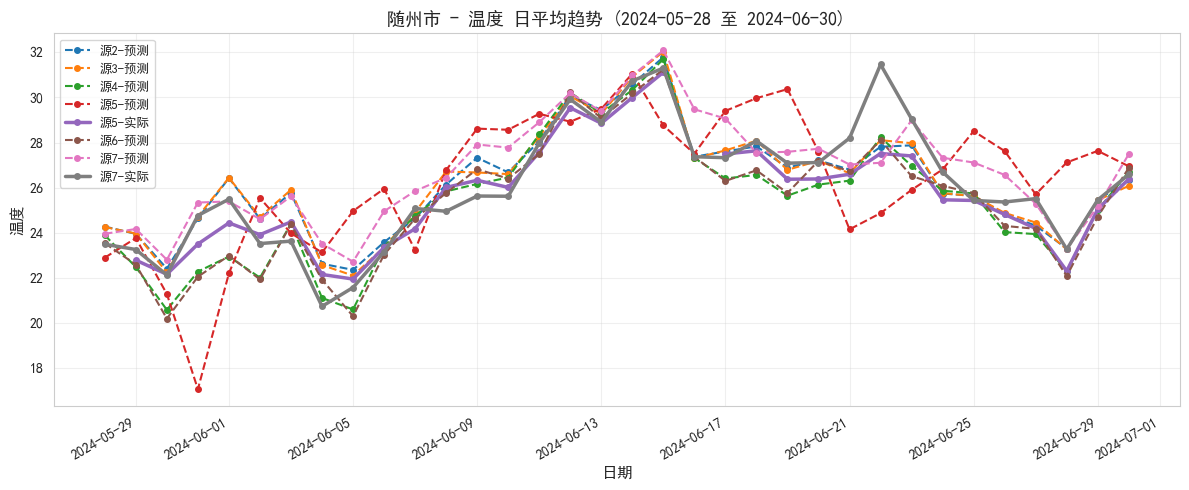

In [7]:
def plot_weather_timeseries(df_weather, city, weather_type, 
                            data_sources=None,
                            plot_type='both',
                            start_date=None,
                            end_date=None):
    """
    绘制气象数据时间序列趋势曲线（按日平均）
    
    参数:
        df_weather: 气象数据    
        city: 城市名称，如 '武汉市'
        weather_type: 气象类型，如 '温度'
        data_sources: 数据源列表，如 ['源2', '源5']，None表示全部
        plot_type: 'forecast'=仅预测, 'actual'=仅实际, 'both'=两者都画
        start_date: 起始日期 '2024-05-28'
        end_date: 结束日期 '2024-06-01'
    """
    
    # 读取数据
    df = df_weather.copy()
    df['日期'] = pd.to_datetime(df['日期'])
    
    # 日期筛选
    if start_date:
        df = df[df['日期'] >= start_date]
    if end_date:
        df = df[df['日期'] <= end_date]
    
    # 筛选列
    pattern = f"{city}-{weather_type}"
    all_cols = [col for col in df.columns if pattern in col]
    
    # 根据data_sources和plot_type筛选
    selected_cols = []
    for col in all_cols:
        # 检查数据源
        if data_sources and not any(src in col for src in data_sources):
            continue
        
        # 检查类型
        is_forecast = '预测' in col
        is_actual = '实际' in col
        
        if plot_type == 'forecast' and is_forecast:
            selected_cols.append(col)
        elif plot_type == 'actual' and is_actual:
            selected_cols.append(col)
        elif plot_type == 'both':
            selected_cols.append(col)
    
    if len(selected_cols) == 0:
        print("没有符合条件的列")
        return
    
    # 按日期计算平均值
    daily_data = df.groupby('日期')[selected_cols].mean().reset_index()
    
    # 绘制
    fig, ax = plt.subplots(figsize=(12, 5))
    
    for col in selected_cols:
        # 简化标签
        label = col.replace(f"{city}-{weather_type}-", "")
        
        # 线型
        linestyle = '-' if '实际' in col else '--'
        linewidth = 2.5 if '实际' in col else 1.5
        
        ax.plot(daily_data['日期'], daily_data[col], 
                label=label, 
                linestyle=linestyle,
                linewidth=linewidth,
                marker='o',
                markersize=4)
    
    # 标题和标签
    title = f"{city} - {weather_type} 日平均趋势"
    if start_date and end_date:
        title += f" ({start_date} 至 {end_date})"
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('日期', fontsize=11)
    ax.set_ylabel(weather_type, fontsize=11)
    
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

plot_weather_timeseries(
    df_weather,
    city="随州市",
    weather_type="温度",
    data_sources=['源1', '源2', '源3', '源4', '源5', '源6', '源7'],
    plot_type='both',
    start_date='2024-05-28',
    end_date='2024-06-30'
)

In [8]:
import re
from collections import defaultdict
from itertools import combinations
from scipy.stats import spearmanr


def calculate_smape(y_true, y_pred):
    """
    计算 sMAPE。
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    denominator = np.abs(y_true) + np.abs(y_pred)
    mask = denominator != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(
        2 * np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]
    ) * 100


def parse_column_name(col_name):
    """
    解析列名。
    假设列名格式为：
    城市-气象类型-源X-预测
    城市-气象类型-源X-实际
    """
    pattern = r'(.+?)-(.+?)-(源\d+)-(预测|实际)'
    match = re.match(pattern, col_name)

    if match:
        return {
            'city': match.group(1),
            'weather_type': match.group(2),
            'source': match.group(3),
            'data_type': match.group(4)
        }

    return None


def calculate_metrics(series1, series2, min_samples=10):
    """
    计算两列之间的 Spearman 相关系数和 sMAPE。
    """
    valid_data = pd.DataFrame({
        's1': series1,
        's2': series2
    }).dropna()

    if len(valid_data) < min_samples:
        return None, None

    corr, _ = spearmanr(valid_data['s1'], valid_data['s2'])

    if pd.isna(corr):
        return None, None

    smape = calculate_smape(valid_data['s1'], valid_data['s2'])

    if pd.isna(smape):
        return None, None

    return corr, smape


def calculate_price_correlation(series, price_series, min_samples=10):
    """
    计算某个气象特征与实时价格之间的绝对 Spearman 相关系数。
    """
    valid_data = pd.DataFrame({
        's': series,
        'price': price_series
    }).dropna()

    if len(valid_data) < min_samples:
        return 0

    corr, _ = spearmanr(valid_data['s'], valid_data['price'])

    if pd.isna(corr):
        return 0

    return abs(corr)


def get_groups_by_city_weather(df):
    """
    第一轮分组：
    按 城市 + 气象类型 分组。
    每组内部区分 actual 和 forecast。
    """
    groups = defaultdict(lambda: {'actual': [], 'forecast': []})

    for col in df.columns:
        parsed = parse_column_name(col)
        if parsed is None:
            continue

        key = (parsed['city'], parsed['weather_type'])

        if parsed['data_type'] == '实际':
            groups[key]['actual'].append(col)
        elif parsed['data_type'] == '预测':
            groups[key]['forecast'].append(col)

    return groups


def get_groups_by_weather_type(df):
    """
    第二轮分组：
    只按气象类型分组，允许跨城市比较。
    """
    groups = defaultdict(list)

    for col in df.columns:
        parsed = parse_column_name(col)
        if parsed is None:
            continue

        groups[parsed['weather_type']].append(col)

    return groups


def find_best_redundant_pair(
    df,
    cols,
    price_series,
    corr_threshold,
    smape_threshold
):
    """
    在给定列集合中，寻找一对最适合简化的列。

    规则：
    1. 两列满足 corr > corr_threshold 且 smape < smape_threshold；
    2. 保留与实时价格相关性更高的列；
    3. 在所有可简化对中，优先选择 sMAPE 最小的一对。

    返回：
    {
        'keep_col': 保留列,
        'drop_col': 删除列,
        'corr': corr,
        'smape': smape
    }
    如果没有符合条件的列对，返回 None。
    """
    cols = [c for c in cols if c in df.columns]

    if len(cols) <= 1:
        return None

    price_corrs = {
        col: calculate_price_correlation(df[col], price_series)
        for col in cols
    }

    candidates = []

    for col1, col2 in combinations(cols, 2):
        corr, smape = calculate_metrics(df[col1], df[col2])

        if corr is None:
            continue

        if corr > corr_threshold and smape < smape_threshold:
            if price_corrs.get(col1, 0) >= price_corrs.get(col2, 0):
                keep_col, drop_col = col1, col2
            else:
                keep_col, drop_col = col2, col1

            candidates.append({
                'keep_col': keep_col,
                'drop_col': drop_col,
                'corr': corr,
                'smape': smape
            })

    if not candidates:
        return None

    candidates.sort(key=lambda x: x['smape'])
    return candidates[0]


def simplify_pairs_iteratively_with_fill(
    df,
    cols,
    price_series,
    corr_threshold,
    smape_threshold
):
    """
    对一组列进行迭代简化。

    每次：
    1. 找到一对符合条件的列；
    2. 保留与实时价格相关性更高的列；
    3. 删除列之前，用删除列 fillna 填充保留列；
    4. 删除该列；
    5. 重新计算，直到没有符合条件的列对。

    返回需要删除的列集合。
    """
    cols = [c for c in cols if c in df.columns]
    cols_to_drop = set()

    while True:
        remaining_cols = [
            c for c in cols
            if c in df.columns and c not in cols_to_drop
        ]

        if len(remaining_cols) <= 1:
            break

        best_pair = find_best_redundant_pair(
            df=df,
            cols=remaining_cols,
            price_series=price_series,
            corr_threshold=corr_threshold,
            smape_threshold=smape_threshold
        )

        if best_pair is None:
            break

        keep_col = best_pair['keep_col']
        drop_col = best_pair['drop_col']

        # 关键要求：删除前，用删除列填充保留列
        df[keep_col] = df[keep_col].fillna(df[drop_col])

        cols_to_drop.add(drop_col)

    return cols_to_drop


def fill_actuals_with_forecasts_iteratively(
    df,
    actual_cols,
    forecast_cols,
    corr_threshold,
    smape_threshold
):
    """
    第一阶段：
    预测源填充实际源。

    规则：
    1. 限定在同一城市 + 同一气象类型内部；
    2. 寻找与实际源满足条件的预测源；
    3. 用预测源填充实际源；
    4. 删除该预测源；
    5. 循环直到没有符合条件的预测源。

    返回需要删除的预测列集合。
    """
    actual_cols = [c for c in actual_cols if c in df.columns]
    forecast_cols = [c for c in forecast_cols if c in df.columns]

    cols_to_drop = set()

    while True:
        candidates = []

        remaining_forecasts = [
            c for c in forecast_cols
            if c in df.columns and c not in cols_to_drop
        ]

        if not actual_cols or not remaining_forecasts:
            break

        for actual_col in actual_cols:
            if actual_col not in df.columns:
                continue

            for forecast_col in remaining_forecasts:
                corr, smape = calculate_metrics(
                    df[actual_col],
                    df[forecast_col]
                )

                if corr is None:
                    continue

                if corr > corr_threshold and smape < smape_threshold:
                    candidates.append({
                        'actual_col': actual_col,
                        'forecast_col': forecast_col,
                        'corr': corr,
                        'smape': smape
                    })

        if not candidates:
            break

        # 优先选择 sMAPE 最小的预测源进行填充
        candidates.sort(key=lambda x: x['smape'])
        best = candidates[0]

        actual_col = best['actual_col']
        forecast_col = best['forecast_col']

        # 关键要求：删除预测源前，用预测源填充实际源
        df[actual_col] = df[actual_col].fillna(df[forecast_col])

        cols_to_drop.add(forecast_col)

    return cols_to_drop


def align_price_series(df_weather, df_market, price_col):
    """
    对齐气象数据和实时价格数据。
    """
    if ('日期' in df_weather.columns and '日期' in df_market.columns and
        '时段' in df_weather.columns and '时段' in df_market.columns):
        merged_df = pd.merge(
            df_weather,
            df_market[['日期', '时段', price_col]],  # 包含时段列
            on=['日期', '时段'],  # 按两列合并
            how='inner'
        )
        price_series = merged_df[price_col]
        weather_df = merged_df.drop(columns=[price_col])

        return weather_df, price_series

    weather_df = df_weather.reset_index(drop=True).copy()
    price_series = df_market[price_col].reset_index(drop=True)

    min_len = min(len(weather_df), len(price_series))
    weather_df = weather_df.iloc[:min_len].reset_index(drop=True)
    price_series = price_series.iloc[:min_len].reset_index(drop=True)

    return weather_df, price_series


def simplify_weather_features(
    df_weather,
    df_market,
    corr_threshold=0.90,
    smape_threshold=20,
    price_col='平均出清价格-实时（元/MWh）'
):
    """
    完整版气象特征简化函数。

    第一轮：
    限定在 城市 + 气象类型 内部进行。

    第一阶段：
    实际源 vs 预测源。
    找到符合条件的预测源，用预测源填充实际源，然后删除预测源。
    循环直到没有符合条件的预测源。

    第二阶段：
    预测源之间。
    符合条件时，保留与实时价格相关性最高的预测源。
    删除其他预测源前，先用删除列填充保留列。
    循环直到没有符合条件的预测源。

    第三阶段：
    实际源之间。
    符合条件时，保留与实时价格相关性最高的实际源。
    删除其他实际源前，先用删除列填充保留列。
    循环直到没有符合条件的实际源。

    第二轮：
    只限定气象类型，跨城市简化。
    对同一气象类型下的所有剩余特征进行简化。
    每次删除前，都用删除列填充保留列。
    """

    simplified_df, price_series = align_price_series(
        df_weather=df_weather,
        df_market=df_market,
        price_col=price_col
    )

    original_count = simplified_df.shape[1]

    first_round_drop = set()

    # ======================
    # 第一轮：城市 + 气象类型
    # ======================
    city_weather_groups = get_groups_by_city_weather(simplified_df)

    for (city, weather_type), cols in city_weather_groups.items():
        actual_cols = [
            c for c in cols['actual']
            if c in simplified_df.columns and c not in first_round_drop
        ]

        forecast_cols = [
            c for c in cols['forecast']
            if c in simplified_df.columns and c not in first_round_drop
        ]

        # ---------- 第一阶段：预测源填充实际源 ----------
        drop_forecasts_stage1 = fill_actuals_with_forecasts_iteratively(
            df=simplified_df,
            actual_cols=actual_cols,
            forecast_cols=forecast_cols,
            corr_threshold=corr_threshold,
            smape_threshold=smape_threshold
        )

        first_round_drop.update(drop_forecasts_stage1)

        # ---------- 第二阶段：剩余预测源之间简化 ----------
        remaining_forecasts = [
            c for c in forecast_cols
            if c in simplified_df.columns and c not in first_round_drop
        ]

        drop_forecasts_stage2 = simplify_pairs_iteratively_with_fill(
            df=simplified_df,
            cols=remaining_forecasts,
            price_series=price_series,
            corr_threshold=corr_threshold,
            smape_threshold=smape_threshold
        )

        first_round_drop.update(drop_forecasts_stage2)

        # ---------- 第三阶段：实际源之间简化 ----------
        remaining_actuals = [
            c for c in actual_cols
            if c in simplified_df.columns and c not in first_round_drop
        ]

        drop_actuals_stage3 = simplify_pairs_iteratively_with_fill(
            df=simplified_df,
            cols=remaining_actuals,
            price_series=price_series,
            corr_threshold=corr_threshold,
            smape_threshold=smape_threshold
        )

        first_round_drop.update(drop_actuals_stage3)

    # 删除第一轮标记列
    simplified_df = simplified_df.drop(
        columns=[c for c in first_round_drop if c in simplified_df.columns]
    )

    # ======================
    # 第二轮：只按气象类型跨城市简化
    # ======================
    second_round_drop = set()

    weather_type_groups = get_groups_by_weather_type(simplified_df)

    for weather_type, cols in weather_type_groups.items():
        remaining_cols = [
            c for c in cols
            if c in simplified_df.columns and c not in second_round_drop
        ]

        drop_cols = simplify_pairs_iteratively_with_fill(
            df=simplified_df,
            cols=remaining_cols,
            price_series=price_series,
            corr_threshold=corr_threshold,
            smape_threshold=smape_threshold
        )

        second_round_drop.update(drop_cols)

    simplified_df = simplified_df.drop(
        columns=[c for c in second_round_drop if c in simplified_df.columns]
    )

    final_count = simplified_df.shape[1]
    dropped_count = original_count - final_count

    print(
        f"特征简化完成: 原始{original_count}列 → 最终{final_count}列, "
        f"删除{dropped_count}列"
    )
    print(
        f"第一轮删除 {len(first_round_drop)} 列，"
        f"第二轮删除 {len(second_round_drop)} 列"
    )

    return simplified_df


def check_remaining_redundancy(
    df,
    corr_threshold=0.90,
    smape_threshold=20,
    scope='weather_type'
):
    """
    校验最终是否仍存在冗余特征。

    scope='weather_type':
        在同一气象类型下检查，包括跨城市。

    scope='all':
        所有可解析气象列之间都检查。
    """
    redundant_pairs = []

    if scope == 'weather_type':
        groups = get_groups_by_weather_type(df)
    elif scope == 'all':
        groups = {
            'all': [
                col for col in df.columns
                if parse_column_name(col) is not None
            ]
        }
    else:
        raise ValueError("scope 只能是 'weather_type' 或 'all'")

    for group_name, cols in groups.items():
        cols = [c for c in cols if c in df.columns]

        for col1, col2 in combinations(cols, 2):
            corr, smape = calculate_metrics(df[col1], df[col2])

            if corr is None:
                continue

            if corr > corr_threshold and smape < smape_threshold:
                redundant_pairs.append({
                    'group': group_name,
                    'col1': col1,
                    'col2': col2,
                    'corr': corr,
                    'smape': smape
                })

    if redundant_pairs:
        print(f"仍存在 {len(redundant_pairs)} 对满足冗余条件的特征")
        return pd.DataFrame(redundant_pairs)

    print("校验通过：未发现满足 corr 和 sMAPE 条件的冗余特征")
    return pd.DataFrame()

df_weather_simplified = simplify_weather_features(
    df_weather=df_weather,
    df_market=df_market,
    corr_threshold=0.85,
    smape_threshold=20,
    price_col='平均出清价格-实时（元/MWh）'
)

print(f"简化后数据shape: {df_weather_simplified.shape}")

特征简化完成: 原始311列 → 最终161列, 删除150列
第一轮删除 101 列，第二轮删除 49 列
简化后数据shape: (9576, 161)


In [83]:
redundancy_check = check_remaining_redundancy(
    df=df_weather_simplified,
    corr_threshold=0.85,
    smape_threshold=15,
    scope='weather_type'
)

redundancy_check

校验通过：未发现满足 corr 和 sMAPE 条件的冗余特征


""


In [11]:
# 检查缺失值
missing_data = df_weather_simplified.isnull().sum()
missing_percentage = (missing_data / len(df_weather_simplified)) * 100

print("=== 缺失值统计 ===")
missing_info = pd.DataFrame({
    '缺失数量': missing_data,
    '缺失比例(%)': missing_percentage.round(2)
})
missing_info = missing_info[missing_info['缺失数量'] > 0].sort_values('缺失比例(%)', ascending=False)

if len(missing_info) > 0:
    display(missing_info)
else:
    print("✓ 无缺失值")

# 保留缺失率小于等于15%的列
df_weather_simplified = df_weather_simplified.loc[:, missing_percentage[missing_percentage <= 15].index]

=== 缺失值统计 ===


,缺失数量,缺失比例(%)
黄冈市-总云量-源2-预测,922,9.63
武汉市-总云量-源2-预测,907,9.47
孝感市-总云量-源2-预测,896,9.36
荆门市-总云量-源2-预测,896,9.36
随州市-总云量-源2-预测,887,9.26
...,...,...
武汉市-辐照度-源3-预测,126,1.32
随州市-辐照度-源3-预测,126,1.32
黄冈市-辐照度-源3-预测,126,1.32
荆门市-总云量-源5-预测,13,0.14


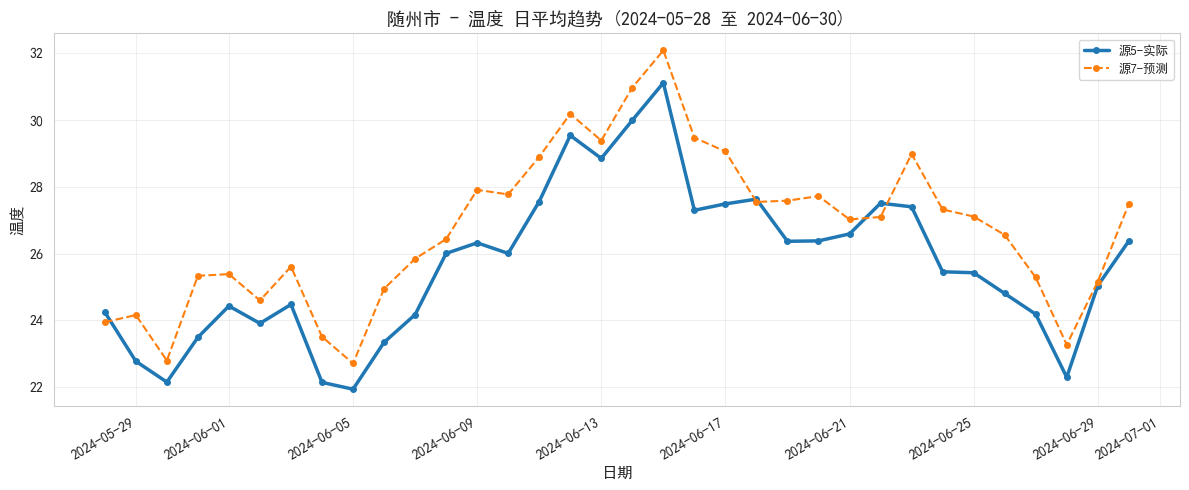

In [12]:
plot_weather_timeseries(
    df_weather_simplified,
    city="随州市",
    weather_type="温度",
    data_sources=['源1', '源2', '源3', '源4', '源5', '源6', '源7'],
    plot_type='both',
    start_date='2024-05-28',
    end_date='2024-06-30'
)

In [13]:
# 选择城市和气象类型
city = "随州市"  # 可选: 孝感市, 宜昌市, 武汉市, 荆州市等
weather_type = "温度"  # 可选: 温度, 风速, 总云量, 相对湿度, 压强, 辐照度, 降雨量

# 分析数据
results = analyze_weather_data(df_weather_simplified, city, weather_type)
'''
# 导出结果到Excel
if results:
    output_path = f"../../results/logs/{city}_{weather_type}_数据源对比分析.xlsx"
    export_results_to_excel(results, output_path)
'''

找到以下列: ['随州市-温度-源5-实际', '随州市-温度-源7-预测']

预测数据源: ['随州市-温度-源7-预测']
实际数据源: ['随州市-温度-源5-实际']

1. 预测数据源之间的比较

2. 预测与实际数据之间的比较

随州市-温度-源7-预测 vs 随州市-温度-源5-实际:
  Spearman相关系数: 0.9721 (p值: 0.0000)
  RMSE: 2.5240
  sMAPE: 23.16%
  样本数: 8992


'\n# 导出结果到Excel\nif results:\n    output_path = f"../../results/logs/{city}_{weather_type}_数据源对比分析.xlsx"\n    export_results_to_excel(results, output_path)\n'

In [14]:
def analyze_dayahead_vs_realtime(df, feature_pairs=None):
    """
    计算实时和日前特征之间的Spearman相关系数和sMAPE
    
    参数:
        df: DataFrame，包含实时和日前数据
        feature_pairs: 字典，格式为 {'实时列名': '日前列名'}，如果为None则自动匹配
    
    返回:
        results_df: 包含分析结果的DataFrame
    """
    
    # 如果没有提供特征对，自动匹配（根据列名规则）
    if feature_pairs is None:
        # 找出所有-实时和-日前列
        realtime_cols = [col for col in df.columns if '-实时' in col or '实时' in col]
        dayahead_cols = [col for col in df.columns if '-日前' in col or '日前' in col]
        
        feature_pairs = {}
        for rt_col in realtime_cols:
            # 尝试找到对应的日前列
            for da_col in dayahead_cols:
                # 提取特征名称（去掉-实时/-日前后缀）
                rt_feature = rt_col.replace('-实时', '').replace('实时', '').replace('（元/MWh）', '')
                da_feature = da_col.replace('-日前', '').replace('日前', '').replace('（元/MWh）', '')
                
                if rt_feature == da_feature and '价格' not in rt_col:
                    feature_pairs[rt_col] = da_col
                    break
    
    results = []
    
    print("="*70)
    print("实时数据 vs 日前数据 相关性分析")
    print("="*70)
    
    for realtime_col, dayahead_col in feature_pairs.items():
        if realtime_col not in df.columns or dayahead_col not in df.columns:
            print(f"\n⚠️ 跳过: {realtime_col} 或 {dayahead_col} 不存在")
            continue
        
        # 获取有效数据（去除缺失值）
        valid_data = df[[realtime_col, dayahead_col]].dropna()
        
        if len(valid_data) < 2:
            print(f"\n⚠️ {realtime_col} vs {dayahead_col}: 有效样本不足")
            continue
        
        # 计算Spearman相关系数
        corr, p_value = spearmanr(valid_data[realtime_col], valid_data[dayahead_col])
        # 计算sMAPE（以实时为真实值，日前为预测值）
        smape = calculate_smape(valid_data[realtime_col], valid_data[dayahead_col])
        
        result = {
            '实时特征': realtime_col,
            '日前特征': dayahead_col,
            'Spearman相关系数': round(corr, 4),
            'P值': round(p_value, 4),
            'sMAPE(%)': round(smape, 2),
            '样本数': len(valid_data)
        }
        results.append(result)
        
        # 打印结果
        print(f"\n【{realtime_col}】 vs 【{dayahead_col}】")
        print(f"  Spearman相关系数: {corr:.4f} (p值: {p_value:.4f})")
        print(f"  sMAPE: {smape:.2f}%")
    
    # 转换为DataFrame
    results_df = pd.DataFrame(results)
    
    return results_df

results = analyze_dayahead_vs_realtime(df_market)

实时数据 vs 日前数据 相关性分析

【系统负荷-实时】 vs 【系统负荷-日前】
  Spearman相关系数: 0.9174 (p值: 0.0000)
  sMAPE: 5.65%

【风电出力-实时】 vs 【风电出力-日前】
  Spearman相关系数: 0.9139 (p值: 0.0000)
  sMAPE: 30.96%

【光伏出力-实时】 vs 【光伏出力-日前】
  Spearman相关系数: 0.9339 (p值: 0.0000)
  sMAPE: 96.99%

【水电出力-实时】 vs 【水电出力-日前】
  Spearman相关系数: 0.9484 (p值: 0.0000)
  sMAPE: 9.09%

【联络线计划-实时】 vs 【联络线计划-日前】
  Spearman相关系数: 0.8947 (p值: 0.0000)
  sMAPE: 19.69%

【非市场化机组出力-实时】 vs 【非市场化机组出力-日前】
  Spearman相关系数: 0.9500 (p值: 0.0000)
  sMAPE: 7.83%


In [15]:
# 用日前数据填充实时数据的缺失值（实时价格除外）
def fill_realtime_with_day_ahead(df_market):
    """
    用日前数据填充对应的实时数据缺失值
    注意：平均出清价格-实时 不填充，保持独立
    """
    # 定义需要填充的列对（实时列: 日前列）
    fill_pairs = {
        '水电出力-实时': '水电出力-日前',
        '风电出力-实时': '风电出力-日前',
        '联络线计划-实时': '联络线计划-日前',
        '系统负荷-实时': '系统负荷-日前',  
        '非市场化机组出力-实时': '非市场化机组出力-日前',  
    }
    
    fill_count = {}
    
    for realtime_col, dayahead_col in fill_pairs.items():
        if realtime_col in df_market.columns and dayahead_col in df_market.columns:
            # 统计填充前的缺失值数量
            missing_before = df_market[realtime_col].isnull().sum()
            
            # 用日前数据填充实时数据的缺失值
            df_market[realtime_col] = df_market[realtime_col].fillna(df_market[dayahead_col])
            
            # 统计实际填充的数量
            missing_after = df_market[realtime_col].isnull().sum()
            filled_count = missing_before - missing_after
            
            fill_count[realtime_col] = filled_count
    
    # 打印汇总
    print("\n" + "="*50)
    print("填充汇总：")
    total_filled = sum(fill_count.values())
    print(f"总共填充了 {total_filled} 个缺失值")
    print("="*50)
    
    return df_market

# 执行填充
df_market = fill_realtime_with_day_ahead(df_market)

# 查看填充后的缺失值情况
print("\n填充后的缺失值统计：")
missing_after = df_market.isnull().sum()
missing_info = pd.DataFrame({
    '缺失数量': missing_after,
    '缺失比例(%)': (missing_after / len(df_market) * 100).round(2)
})
missing_info = missing_info[missing_info['缺失数量'] > 0].sort_values('缺失比例(%)', ascending=False)
display(missing_info)


填充汇总：
总共填充了 4716 个缺失值

填充后的缺失值统计：


,缺失数量,缺失比例(%)
光伏出力-实时,1224,12.78
平均出清价格-日前（元/MWh）,216,2.26
光伏出力-日前,72,0.75
风电出力-日前,72,0.75
联络线计划-日前,72,0.75
平均出清价格-实时（元/MWh）,48,0.50


In [16]:
columns_to_drop = ['水电出力-日前', '系统负荷-日前', '非市场化机组出力-日前',
 '平均出清价格-日前（元/MWh）', '风电出力-日前', '光伏出力-日前', '联络线计划-日前', 
 '时间戳', '年']
df_market_simplified = df_market.drop(columns=columns_to_drop)

df_merged = pd.merge(
    df_weather_simplified, 
    df_market_simplified, 
    on=['日期', '时段'], 
    how='inner'  # 只保留两个表都有的记录
)

print('简化后的市场总表与气象总表合并后的数据集形状：')
print(df_merged.shape)

简化后的市场总表与气象总表合并后的数据集形状：
(9576, 126)


In [17]:
# 查看合并后的缺失值情况
print("\n合并后的缺失值统计：")
missing_after = df_merged.isnull().sum()
missing_info = pd.DataFrame({
    '缺失数量': missing_after,
    '缺失比例(%)': (missing_after / len(df_merged) * 100).round(2)
})
missing_info = missing_info[missing_info['缺失数量'] > 0].sort_values('缺失比例(%)', ascending=False)
display(missing_info)


合并后的缺失值统计：


,缺失数量,缺失比例(%)
光伏出力-实时,1224,12.78
黄冈市-总云量-源2-预测,922,9.63
武汉市-总云量-源2-预测,907,9.47
荆门市-总云量-源2-预测,896,9.36
孝感市-总云量-源2-预测,896,9.36
...,...,...
荆州市-辐照度-源3-预测,126,1.32
黄冈市-辐照度-源3-预测,126,1.32
平均出清价格-实时（元/MWh）,48,0.50
荆门市-总云量-源5-预测,13,0.14


In [19]:
df_interpolated = df_merged.interpolate(method='linear', limit_direction='both')
df_interpolated = df_interpolated.round(1)
df_interpolated.to_csv('../../data/processed/processed_data.csv', index=False)
